# 06 Three-Way Comparison: Detection & Explanation

**Pure Faster R-CNN** vs **Neuro-Symbolic (FRCNN + SODT)** vs **Grad-CAM**

| Aspect | Matchup | Question | Metrics |
|---|---|---|---|
| **Detection** | FRCNN vs NeSy | Does the tree cost accuracy? | mAP, Precision, Recall, F1 |
| **Explanation (4a)** | SODT vs GradCAM vs Random | Is SODT's explanation at least as faithful/grounded as GradCAM's? | Sufficiency, Necessity, Pointing, IoU |
| **Explanation (4b)** | SODT only, per node | Does the region each step weighs actually decide that step? | Necessity flip, Deletion/Insertion AUC — no GradCAM equivalent, it has no steps |

Per-image views: detection (FRCNN | NeSy | Truth), explanation (tree + per-step heatmap | GradCAM).

SODT's map follows `USE_FPN_HEATMAP` (exact FPN or 7×7 grid); ablation = rerun with the flag negated.

In [1]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import random
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import time as _time
import torch

from notebooks.util import resolve_root
from neuro.config import NeuroConfig, NeuroTrainConfig
from neuro.inference import load_checkpoint_model
from neuro.prepare_dataset import PCBDataset
from neuro.preprocess_dataset import test_preprocess
from neurosym.inference import (
    load_neurosymbolic_detector,
    run_neurosymbolic_inference,
    explain_hybrid_detections,
    compute_node_fpn_maps,
    select_detection_indices,
)
from neurosym.visualization import (
    image_to_array,
    heatmap_to_array,
    draw_numbered_detections,
    draw_neurosymbolic_explanation,
    zoom_axis_to_box,
    draw_ground_truth_boxes,
    lookup_ground_truth,
)
from gradcam.gradcam import GradCAM
from util.config import load_yaml
from util.device import select_device

from torchvision.ops import box_iou as _box_iou
from tqdm import tqdm as _tqdm
from neuro.train import evaluate_model
from neuro.utils import detection_collate_fn
from torch.utils.data import DataLoader
from gradcam.evaluation import evaluate_gradcam_faithfulness, evaluate_shared_localization

PROJECT_ROOT = resolve_root()

## 1. Load Models

In [2]:
neuro_config = load_yaml(Path("neuro.yaml"), NeuroConfig)
train_config = load_yaml(Path("neuro_train.yaml"), NeuroTrainConfig)

device = select_device(train_config["device"])
detector_ckpt = PROJECT_ROOT / "checkpoints" / "neuro" / "neuro_chosen.pt"
symbolic_ckpt = PROJECT_ROOT / "checkpoints" / "symbolic" / "run2.pt"  # notebooks/03 retrain after the class-name fix

class_names = tuple(train_config["dataset"]["class_names"])
preprocess = test_preprocess()

# --- Pure Faster R-CNN ---
frcnn_model, _ = load_checkpoint_model(
    detector_ckpt,
    model_config_path=Path("neuro.yaml"),
    train_config_path=Path("neuro_train.yaml"),
    device=str(device),
)
print("✓ Pure Faster R-CNN loaded")

# --- Neuro-Symbolic (SODT) ---
hybrid_model, _ = load_neurosymbolic_detector(
    detector_checkpoint_path=detector_ckpt,
    neuro_config=neuro_config,
    train_config=train_config,
    symbolic_checkpoint_path=symbolic_ckpt,
    device=str(device),
)
print("✓ Neuro-Symbolic (Faster R-CNN + SODT) loaded")

# A tree trained before the class-name fix (or on a stale export) carries the old order.
assert tuple(hybrid_model.symbolic_tree.class_names[1:]) == class_names, (
    f"SODT class order {hybrid_model.symbolic_tree.class_names[1:]} != config {class_names}: "
    "wrong/stale symbolic checkpoint — point to the run notebook 03 just trained."
)

# --- Grad-CAM ---
gradcam = GradCAM(frcnn_model, device=str(device))
print("✓ Grad-CAM initialised (FPN level each RoI is pooled from)")

✓ Pure Faster R-CNN loaded
✓ Neuro-Symbolic (Faster R-CNN + SODT) loaded
✓ Grad-CAM initialised (hooked into layer4/c5)


## 2. Prepare Test Data

In [ ]:
from util.seed import seed_everything

test_dataset = PCBDataset(train_config, split_file="test.txt")
test_dataset.add_preprocess(preprocess)

N = 4  # Number of test images to compare
USE_FPN_HEATMAP = True  # True = exact FPN heatmap, False = pooled 7x7 grid heatmap; drives SODT metrics (4a/4b) and visuals (5/6)
SODT_MAP = "exact FPN" if USE_FPN_HEATMAP else "grid 7x7"
print(f"SODT heatmap: {SODT_MAP}")
seed_everything(42)
sample_indices = random.sample(range(len(test_dataset)), k=min(N, len(test_dataset)))

print(f"Test set size : {len(test_dataset)}")
print(f"Selected indices: {sample_indices}")

## 3. Metrics Computation
Detection (FRCNN vs NeSy) first; explanation (4a head-to-head vs GradCAM, 4b per-step for SODT
only) after.

In [ ]:
from torchmetrics.detection import MeanAveragePrecision
from neuro.train import count_detection_matches, _confusion_and_per_class

SCORE_THRESHOLD = train_config["evaluation"]["precision_score_threshold"]  # P/R operating point; explanations use it too

# ── Detection Metrics: FRCNN (batched) ──
test_loader = DataLoader(
    test_dataset,
    batch_size=train_config["dataset"]["batch_size"],
    shuffle=False,
    collate_fn=detection_collate_fn,
)

print("Evaluating Faster R-CNN detection metrics...")
frcnn_det_metrics = evaluate_model(frcnn_model, test_loader, device, train_config)


# ── NeSy detection metrics pass ──

tree = hybrid_model.symbolic_tree
evaluation_config = train_config["evaluation"]
num_classes = len(class_names) + 1

# Detection accumulators
nesy_coco = MeanAveragePrecision(
    iou_type="bbox",
    backend="pycocotools",
    class_metrics=evaluation_config["class_metrics"],
)
nesy_paper = MeanAveragePrecision(
    iou_type="bbox",
    backend="pycocotools",
    iou_thresholds=evaluation_config["iou_thresholds"],
)
nesy_conf_matrix = torch.zeros(num_classes, num_classes, dtype=torch.int64)
nesy_class_tp = torch.zeros(num_classes, dtype=torch.int64)
nesy_class_fp = torch.zeros(num_classes, dtype=torch.int64)
nesy_class_fn = torch.zeros(num_classes, dtype=torch.int64)
nesy_tp = nesy_fp = nesy_fn = 0

print("Running NeSy detection metrics pass...")
for batch_images, batch_targets in _tqdm(test_loader, desc="NeSy detection eval"):
    with torch.inference_mode():
        outputs = hybrid_model([img.to(device) for img in batch_images])

    for det, target in zip(outputs, batch_targets):
        # ── Detection metrics ──
        prediction = {
            "boxes": det["boxes"].detach().cpu(),
            "scores": det["scores"].detach().cpu(),
            "labels": det["labels"].detach().cpu(),
        }
        ground_truth = {
            "boxes": target["boxes"].detach().cpu(),
            "labels": target["labels"].detach().cpu(),
        }
        nesy_coco.update([prediction], [ground_truth])
        nesy_paper.update([prediction], [ground_truth])

        tp, fp, fn = count_detection_matches(
            prediction,
            ground_truth,
            iou_threshold=evaluation_config["precision_iou"],
            score_threshold=evaluation_config["precision_score_threshold"],
        )
        nesy_tp += tp
        nesy_fp += fp
        nesy_fn += fn
        pc = _confusion_and_per_class(
            prediction,
            ground_truth,
            iou_threshold=evaluation_config["precision_iou"],
            score_threshold=evaluation_config["precision_score_threshold"],
            num_classes=len(class_names),
        )
        nesy_conf_matrix += pc["confusion"]
        nesy_class_tp += pc["class_tp"]
        nesy_class_fp += pc["class_fp"]
        nesy_class_fn += pc["class_fn"]

# ── Build NeSy detection metrics dict ──
nesy_coco_out = nesy_coco.compute()
nesy_paper_out = nesy_paper.compute()
nesy_precision = nesy_tp / max(nesy_tp + nesy_fp, 1)
nesy_recall = nesy_tp / max(nesy_tp + nesy_fn, 1)
all_class_names = ["__background__", *class_names]

nesy_det_metrics = {
    "mAP@0.5:0.95": nesy_coco_out["map"].item(),
    "mAP@0.5": nesy_coco_out["map_50"].item(),
    "AP75": nesy_coco_out["map_75"].item(),
    "AP@50:5:85": nesy_paper_out["map"].item(),
    "precision": nesy_precision,
    "recall": nesy_recall,
    "mar_100": nesy_coco_out["mar_100"].item(),
    "f1_score": 2
    * nesy_precision
    * nesy_recall
    / max(nesy_precision + nesy_recall, 1e-10),
    "confusion_matrix": nesy_conf_matrix.tolist(),
    "confusion_matrix_labels": all_class_names,
}

print(
    f"FRCNN  mAP@0.5:0.95 = {frcnn_det_metrics['mAP@0.5:0.95']:.4f}  |  NeSy  mAP@0.5:0.95 = {nesy_det_metrics['mAP@0.5:0.95']:.4f}"
)
print(
    f"FRCNN  precision    = {frcnn_det_metrics['precision']:.4f}  |  NeSy  precision    = {nesy_det_metrics['precision']:.4f}"
)
print(
    f"FRCNN  recall       = {frcnn_det_metrics['recall']:.4f}  |  NeSy  recall       = {nesy_det_metrics['recall']:.4f}"
)

# ── Per-image pipeline timing: batch 1, same SCORE_THRESHOLD, GPU synced ──
# FRCNN = detection | NeSy = detection + exact per-node maps and path map M (lean path,
# same maps as explain_hybrid_detections) | Grad-CAM = FRCNN detection + one map per detection
N_WARMUP = 5
N_RUNS = 3


def _sync():
    if device.type == "cuda":
        torch.cuda.synchronize()


def _time_frcnn(image):
    t0 = _time.perf_counter()
    with torch.inference_mode():
        frcnn_model([image.to(device)])
    _sync()
    return (_time.perf_counter() - t0) * 1000, 0


def _time_nesy(image):
    t0 = _time.perf_counter()
    det = run_neurosymbolic_inference(hybrid_model, [image.to(device)])[0]
    indices = select_detection_indices(det, score_threshold=SCORE_THRESHOLD)
    compute_node_fpn_maps(hybrid_model, det, indices)
    _sync()
    return (_time.perf_counter() - t0) * 1000, len(indices)


def _time_gradcam(image):
    t0 = _time.perf_counter()
    with torch.inference_mode():
        det = frcnn_model([image.to(device)])[0]
    keep = det["scores"] >= SCORE_THRESHOLD
    gradcam.generate(image, det["proposal_boxes_processed"][keep], det["labels"][keep])
    _sync()
    return (_time.perf_counter() - t0) * 1000, int(keep.sum())


PIPELINES = {
    "Faster R-CNN (detection)": _time_frcnn,
    "NeSy (detection + explanation)": _time_nesy,
    "Grad-CAM (detection + explanation)": _time_gradcam,
}
pipeline_times_ms = {name: [[] for _ in range(N_RUNS)] for name in PIPELINES}
pipeline_counts = {name: [] for name in PIPELINES}

hybrid_model.keep_fpn_on_device = True  # FPN maps on the model's device, not copied to CPU
try:
    for i in range(N_WARMUP):  # not recorded
        for fn in PIPELINES.values():
            fn(test_dataset[i][0])

    for run in range(N_RUNS):
        for i in _tqdm(range(len(test_dataset)), desc=f"Pipeline timing {run + 1}/{N_RUNS}"):
            image, _ = test_dataset[i]
            for name, fn in PIPELINES.items():
                ms, n_explained = fn(image)
                pipeline_times_ms[name][run].append(ms)
                pipeline_counts[name].append(n_explained)
finally:
    hybrid_model.keep_fpn_on_device = False

pipeline_mean_ms = {name: float(np.mean(runs)) for name, runs in pipeline_times_ms.items()}
pipeline_std_ms = {name: float(np.std(np.concatenate(runs))) for name, runs in pipeline_times_ms.items()}
frcnn_det_metrics["inference_time_ms"] = pipeline_mean_ms["Faster R-CNN (detection)"]
nesy_det_metrics["inference_time_ms"] = pipeline_mean_ms["NeSy (detection + explanation)"]
gradcam_time_ms = pipeline_mean_ms["Grad-CAM (detection + explanation)"]

print(f"\n{'─' * 92}")
print(f"Time per image (ms): {len(test_dataset)} test images x {N_RUNS} runs, batch 1, {N_WARMUP} warm-up images")
print(f"{'─' * 92}")
for name, runs in pipeline_times_ms.items():
    run_means = " / ".join(f"{np.mean(r):.1f}" for r in runs)
    explained = f"{np.mean(pipeline_counts[name]):.2f}" if "explanation" in name else "-"
    print(
        f"  {name:<36s} {pipeline_mean_ms[name]:7.1f} ± {pipeline_std_ms[name]:5.1f}"
        f"   runs: {run_means}   explained/img: {explained}"
    )
print(f"  Grad-CAM / NeSy ratio: {gradcam_time_ms / nesy_det_metrics['inference_time_ms']:.1f}x")

# ── Chart (Gambar 4.23) ──
fig, ax = plt.subplots(figsize=(8, 4.5))
names = list(pipeline_times_ms)
means = [pipeline_mean_ms[n] for n in names]
stds = [pipeline_std_ms[n] for n in names]
bars = ax.bar(
    [n.replace(" (", "\n(") for n in names], means, yerr=stds, capsize=4,
    color=["#2F6F9F", "#D97941", "#B0B0B0"], edgecolor="white",
)
ax.bar_label(bars, fmt="%.1f ms", padding=3, fontsize=9)
ax.set_ylabel("ms / image (lower = better)")
ax.set_title("Average time per image (mean ± std)", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(m + s for m, s in zip(means, stds)) * 1.2)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
# ── Soft-NMS profiling: why is NeSy's detection lighter than Faster R-CNN's? ──
# Wraps batched_soft_nms (removed again at the end) to log, per image, how many
# candidates enter Soft-NMS and how long it takes; detection only, no heatmaps.
_current = {"tag": None}
_nms_log = {"frcnn": [], "nesy": []}  # (n_candidates, soft_nms_ms) per image
_det_ms = {"frcnn": [], "nesy": []}


def _wrap_soft_nms(detector):
    original = type(detector).batched_soft_nms

    def wrapped(boxes, scores, labels):
        _sync()
        t0 = _time.perf_counter()
        out = original(detector, boxes, scores, labels)
        _sync()
        _nms_log[_current["tag"]].append((int(boxes.shape[0]), (_time.perf_counter() - t0) * 1000))
        return out

    detector.batched_soft_nms = wrapped


# Same object if the hybrid shares the FRCNN instance — wrap it once.
_detectors = {id(frcnn_model): frcnn_model, id(hybrid_model.detector): hybrid_model.detector}
for _d in _detectors.values():
    _wrap_soft_nms(_d)


def _run_detection(tag, model, image):
    _current["tag"] = tag
    _sync()
    t0 = _time.perf_counter()
    with torch.inference_mode():
        model([image.to(device)])
    _sync()
    return (_time.perf_counter() - t0) * 1000


hybrid_model.keep_fpn_on_device = True  # same setting as the timing cell above
try:
    for i in range(N_WARMUP):  # not recorded
        _run_detection("frcnn", frcnn_model, test_dataset[i][0])
        _run_detection("nesy", hybrid_model, test_dataset[i][0])
    for _k in _nms_log:
        _nms_log[_k].clear()
    for i in _tqdm(range(len(test_dataset)), desc="Soft-NMS profiling"):
        image, _ = test_dataset[i]
        _det_ms["frcnn"].append(_run_detection("frcnn", frcnn_model, image))
        _det_ms["nesy"].append(_run_detection("nesy", hybrid_model, image))
finally:
    hybrid_model.keep_fpn_on_device = False
    for _d in _detectors.values():
        del _d.batched_soft_nms  # back to the class method

print(f"\n{'─' * 86}")
print(f"Soft-NMS profiling: {len(test_dataset)} test images, batch 1, detection only (no heatmaps)")
print(f"{'─' * 86}")
print(f"{'':<8}{'cand/img':>16}{'Soft-NMS ms':>16}{'det ms':>16}{'NMS share':>12}{'r(det,cand)':>14}")
for tag in ("frcnn", "nesy"):
    cand = np.array([c for c, _ in _nms_log[tag]], dtype=float)
    nms = np.array([t for _, t in _nms_log[tag]])
    det = np.array(_det_ms[tag])
    r = np.corrcoef(det, cand)[0, 1] if cand.std() > 0 else float("nan")
    print(
        f"{tag:<8}{cand.mean():>9.1f} ± {cand.std():<4.0f}{nms.mean():>9.1f} ± {nms.std():<4.1f}"
        f"{det.mean():>9.1f} ± {det.std():<4.1f}{nms.mean() / det.mean():>12.0%}{r:>14.2f}"
    )
print("(cand/img: candidates entering Soft-NMS | NMS share: Soft-NMS time / detection time |"
      " r: per-image correlation between detection time and candidate count)")

## 4. Metrics Visualization

Detection first (FRCNN vs NeSy). Explanation is two tables: a head-to-head against GradCAM
(4a — one masking protocol on the FPN level for both methods), then a
per-step breakdown that only SODT's six-question structure can answer (4b).

/tmp/ipykernel_33533/1255041892.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


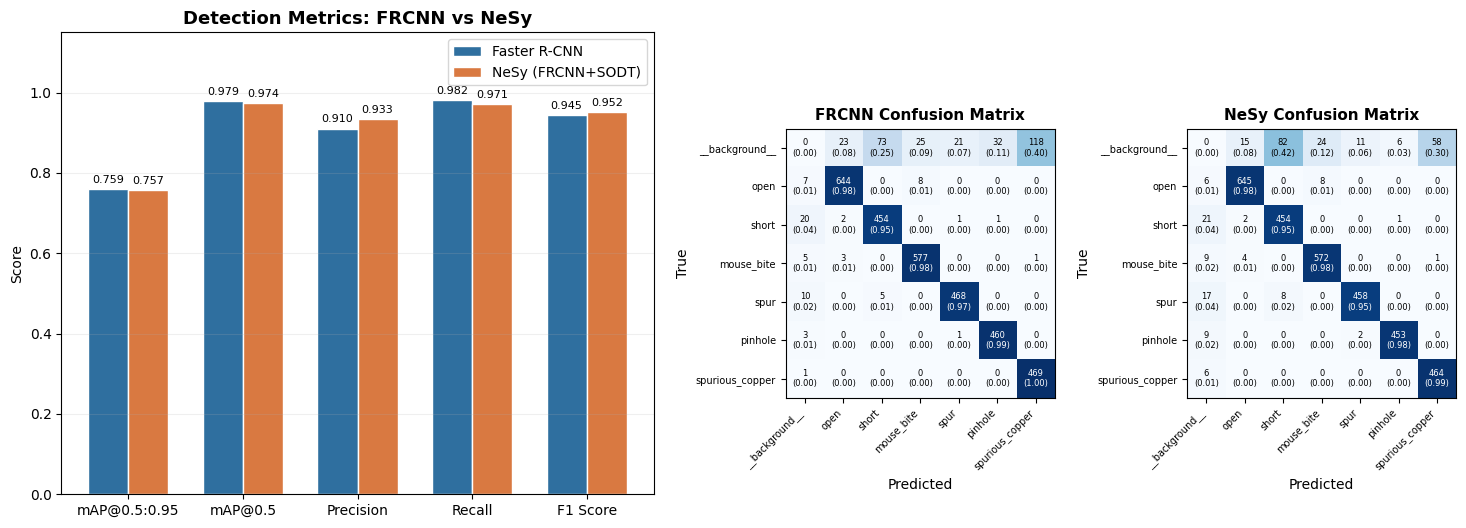

In [5]:
# ── Detection Metrics Bar Chart + Confusion Matrix ──
det_keys = ["mAP@0.5:0.95", "mAP@0.5", "precision", "recall", "f1_score"]
det_labels = ["mAP@0.5:0.95", "mAP@0.5", "Precision", "Recall", "F1 Score"]
frcnn_vals = [frcnn_det_metrics[k] for k in det_keys]
nesy_vals = [nesy_det_metrics[k] for k in det_keys]

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[2.2, 1, 1], wspace=0.35)

# Panel 1: Bar chart
ax = fig.add_subplot(gs[0, 0])
x = np.arange(len(det_labels))
w = 0.35
b1 = ax.bar(
    x - w / 2, frcnn_vals, w, label="Faster R-CNN", color="#2F6F9F", edgecolor="white"
)
b2 = ax.bar(
    x + w / 2,
    nesy_vals,
    w,
    label="NeSy (FRCNN+SODT)",
    color="#D97941",
    edgecolor="white",
)
ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=3, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(det_labels, fontsize=10)
ax.set_ylabel("Score (higher = better)")
ax.set_title("Detection Metrics: FRCNN vs NeSy", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.2)


# Panel 2: FRCNN confusion matrix
def _plot_confusion_matrix(ax, metrics_dict, title):
    cm = np.array(metrics_dict["confusion_matrix"])
    labels = metrics_dict["confusion_matrix_labels"]
    # Include background row/col (index 0)
    cm_defect = cm
    defect_labels = labels
    # Normalize per row (recall-normalized)
    row_sums = cm_defect.sum(axis=1, keepdims=True)
    cm_norm = np.where(row_sums > 0, cm_defect / row_sums, 0.0)

    ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(defect_labels)))
    ax.set_yticks(range(len(defect_labels)))
    ax.set_xticklabels(defect_labels, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(defect_labels, fontsize=7)
    for i in range(cm_defect.shape[0]):
        for j in range(cm_defect.shape[1]):
            color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(
                j,
                i,
                f"{cm_defect[i, j]}\n({cm_norm[i, j]:.2f})",
                ha="center",
                va="center",
                fontsize=6,
                color=color,
            )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")


ax_frcnn_cm = fig.add_subplot(gs[0, 1])
_plot_confusion_matrix(ax_frcnn_cm, frcnn_det_metrics, "FRCNN Confusion Matrix")

# Panel 3: NeSy confusion matrix
ax_nesy_cm = fig.add_subplot(gs[0, 2])
_plot_confusion_matrix(ax_nesy_cm, nesy_det_metrics, "NeSy Confusion Matrix")

plt.tight_layout()
plt.show()

### Ablation: routing-margin scoring off
Leaves hold one label, so without the margin score every detection of a class scores exactly
1.0 — AP and Soft-NMS lose their ordering. Same test loop and metrics as the NeSy pass above,
only `use_routing_margin` flipped; decisions (labels, boxes before Soft-NMS) are identical.
Besides the summary, it reports per-class AP@0.5:0.95 / AP@0.5 / Precision / Recall / F1
(FRCNN | margin on | margin off) and the confusion matrices.

In [ ]:
# ── Routing-margin ablation: same evaluator as FRCNN, score = 1.0 for every detection when off ──
hybrid_model.use_routing_margin = False
try:
    nesy_off = evaluate_model(hybrid_model, test_loader, device, train_config)
finally:
    hybrid_model.use_routing_margin = True
nesy_on = evaluate_model(hybrid_model, test_loader, device, train_config)
nesy_no_margin_metrics = nesy_off

assert np.isclose(nesy_on["mAP@0.5:0.95"], nesy_det_metrics["mAP@0.5:0.95"], atol=1e-4), (
    "margin-on evaluation disagrees with the NeSy pass in section 3"
)

# ── Summary table ──
print(f"{'Metric':<16} {'margin on':>10} {'margin off':>11}")
print("-" * 39)
for key in ["mAP@0.5:0.95", "mAP@0.5", "precision", "recall", "f1_score"]:
    print(f"{key:<16} {nesy_on[key]:>10.4f} {nesy_off[key]:>11.4f}")


# ── Per-class table: FRCNN | margin on | margin off | Δ(on-off) ──
def _f1(p, r):
    return 2 * p * r / max(p + r, 1e-10)


def _per_class(m):
    return {
        "AP@0.5:0.95": m["per_class_AP"],
        "AP@0.5": m["per_class_AP50"],
        "Precision": m["per_class_precision"],
        "Recall": m["per_class_recall"],
        "F1": {c: _f1(m["per_class_precision"][c], m["per_class_recall"][c]) for c in class_names},
    }


pc_frcnn, pc_on, pc_off = _per_class(frcnn_det_metrics), _per_class(nesy_on), _per_class(nesy_off)
for metric in pc_on:
    print(f"\n[{metric}]")
    print(f"{'class':<18}{'FRCNN':>10}{'margin on':>12}{'margin off':>12}{'Δ on-off':>11}")
    print("-" * 63)
    for c in class_names:
        f, on, off = pc_frcnn[metric][c], pc_on[metric][c], pc_off[metric][c]
        print(f"{c:<18}{f:>10.4f}{on:>12.4f}{off:>12.4f}{on - off:>+11.4f}")
    mean = lambda d: float(np.mean([d[c] for c in class_names]))
    print(f"{'(macro mean)':<18}{mean(pc_frcnn[metric]):>10.4f}{mean(pc_on[metric]):>12.4f}"
          f"{mean(pc_off[metric]):>12.4f}{mean(pc_on[metric]) - mean(pc_off[metric]):>+11.4f}")


# ── Confusion matrices (counts; rows = true, cols = predicted, index 0 = background) ──
def _print_cm(title, m):
    cm = np.array(m["confusion_matrix"])
    labels = m["confusion_matrix_labels"]
    print(f"\n{title}")
    print(f"{'true \\ pred':<18}" + "".join(f"{l[:9]:>10}" for l in labels))
    for label, row_vals in zip(labels, cm):
        print(f"{label:<18}" + "".join(f"{v:>10d}" for v in row_vals))


_print_cm("Confusion matrix — margin ON", nesy_on)
_print_cm("Confusion matrix — margin OFF", nesy_off)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
_plot_confusion_matrix(axes[0], frcnn_det_metrics, "FRCNN")
_plot_confusion_matrix(axes[1], nesy_on, "NeSy — margin ON")
_plot_confusion_matrix(axes[2], nesy_off, "NeSy — margin OFF")
plt.tight_layout()
plt.show()

# ── Chart: margin on vs off ──
abl_keys = ["mAP@0.5:0.95", "mAP@0.5", "precision", "recall", "f1_score"]
abl_labels = ["mAP@0.5:0.95", "mAP@0.5", "Precision", "Recall", "F1 Score"]
on_vals = [nesy_on[k] for k in abl_keys]
off_vals = [nesy_off[k] for k in abl_keys]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(abl_keys))
w = 0.35
b_on = ax.bar(x - w / 2, on_vals, w, label="Routing margin ON (score = product of sigmoid(|score|))", color="#2F6F9F", edgecolor="white")
b_off = ax.bar(x + w / 2, off_vals, w, label="Routing margin OFF (score = 1.0)", color="#D97941", edgecolor="white")
ax.bar_label(b_on, fmt="%.3f", padding=3, fontsize=8)
ax.bar_label(b_off, fmt="%.3f", padding=3, fontsize=8)
for xi, on, off in zip(x, on_vals, off_vals):
    ax.text(xi, max(on, off) + 0.08, f"Δ {on - off:+.3f}", ha="center", fontsize=9,
            fontweight="bold", color="#2a7a2a" if on >= off else "#b02020")
ax.set_xticks(x)
ax.set_xticklabels(abl_labels, fontsize=10)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.4)
ax.set_title("Routing-margin ablation: margin on vs off (all metrics: higher = better)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="upper center", ncol=2)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


## 4a. Explanation Faithfulness & Localization: SODT vs GradCAM vs Random
One locked protocol for both methods, fixed before looking at results:

- **Grad-CAM** (Selvaraju et al., 2017) on the FPN level each RoI is pooled from — the last conv
  output the box head reads (pytorch-grad-cam's Faster R-CNN recipe targets the FPN outputs too),
  with the class logit pooled at the detection's **proposal**, where the class call was made.
- **Faithfulness**: all 500 test images; each model's own detections at the P/R operating point
  (score ≥ 0.5, TP and FP alike), explained at their proposals. Top 50% of the proposal's FPN
  pixels (+2 margin) — **necessity** zeroes them and checks for a label flip, **sufficiency** keeps
  only them and checks the label survives (`neurosym/evaluation.py::fpn_necessity_sufficiency`).
- **SODT's path-level map = the per-node panels stacked** (Σ|node map|, `heatmap.path_fpn_map`) —
  or, with `USE_FPN_HEATMAP=False`, the displayed 7×7 grid maps stacked and stretched over the
  box; masking stays on FPN pixels.
- **Controls**: random ranking for both; for SODT also `shuffled_w` (each node's weights
  shuffled) and `activation_only` (|FPN| summed over channels).
- **Localization**: one shared list of loose proposals (IoU 0.05–0.35 to the truth; tight boxes
  make pointing trivial) that both models call a defect — identical RoIs for SODT, Grad-CAM and
  random (`gradcam/evaluation.py::evaluate_shared_localization`).
- **Deletion/Insertion AUC**: how the score moves as the top-ranked pixels are masked or added back.
  SODT's score is its routing confidence, Grad-CAM's is the class probability, so compare each
  only with its own random control. The per-node version is in 4b.

In [ ]:
from neurosym.evaluation import evaluate_faithfulness_fpn_masking

# Locked protocol, both methods: all 500 test images; faithfulness on each
# model's own detections at the P/R operating point (explained at their
# proposals), top-50% FPN pixels masked; localization on one shared list of
# loose proposals (IoU 0.05-0.35) that both models call a defect.
LOOSE_MIN_IOU = 0.05
LOOSE_MAX_IOU = 0.35
eval_images = [test_dataset[i][0] for i in range(len(test_dataset))]
eval_targets = [test_dataset[i][1] for i in range(len(test_dataset))]

# Covers 4a (path-level) and 4b (per-node) in one pass.
fpn_faithfulness = evaluate_faithfulness_fpn_masking(
    hybrid_model,
    eval_images,
    rankings=("exact", "shuffled_w", "activation_only", "random"),
    score_threshold=SCORE_THRESHOLD,
    use_fpn_heatmap=USE_FPN_HEATMAP,
)
gradcam_faithfulness = evaluate_gradcam_faithfulness(
    frcnn_model, gradcam, eval_images, score_threshold=SCORE_THRESHOLD
)
localization = evaluate_shared_localization(
    hybrid_model,
    gradcam,
    eval_images,
    eval_targets,
    min_proposal_iou=LOOSE_MIN_IOU,
    max_proposal_iou=LOOSE_MAX_IOU,
    use_fpn_heatmap=USE_FPN_HEATMAP,
)

sodt_path = fpn_faithfulness["path"]
gcam = gradcam_faithfulness["gradcam"]
gcam_random = gradcam_faithfulness["random"]


def row(label, values):
    cells = "".join(f"{v:>12.4f}" if isinstance(v, float) else f"{v:>12}" for v in values)
    print(f"{label:<30}{cells}")


print(f"\n{'Faithfulness':<30}{'SODT':>12}{'SODT rand':>12}{'GradCAM':>12}{'GCAM rand':>12}")
print("-" * 78)
for key, label in (
    ("necessity_prediction_flip_rate", "Necessity flip"),
    ("sufficiency_prediction_preservation", "Sufficiency preserve"),
    ("deletion_auc", "Deletion AUC (lower=better)"),
    ("insertion_auc", "Insertion AUC (higher=better)"),
    ("evaluated_roi_count", "n (detections)"),
):
    row(label, [sodt_path["exact"][key], sodt_path["random"][key], gcam[key], gcam_random[key]])
row("  control: shuffled_w", [sodt_path["shuffled_w"]["necessity_prediction_flip_rate"], "—", "—", "—"])
row("  control: activation_only", [sodt_path["activation_only"]["necessity_prediction_flip_rate"], "—", "—", "—"])

print(f"\n{'Localization (shared RoIs)':<26}{'SODT':>12}{'GradCAM':>12}{'Random':>12}")
print("-" * 62)
for subset, title in ((lambda r: r, "all"), (lambda r: r["low_gt_coverage"], "low GT coverage")):
    print(f"[{title}]")
    for key, label in (
        ("pointing_score", "Pointing"),
        ("box_grounded_roi_overlap", "IoU overlap"),
        ("evaluated_roi_count", "n"),
    ):
        row(label, [subset(localization[name])[key] for name in ("sodt", "gradcam", "random")])

# ── Chart ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f"Explanation Faithfulness & Localization: SODT ({SODT_MAP}) vs GradCAM vs Random",
    fontsize=13, fontweight="bold", y=1.02,
)

ax = axes[0]
faith_labels = ["Necessity\nFlip Rate\n(higher = better)", "Sufficiency\nPreservation\n(higher = better)"]
keys = ["necessity_prediction_flip_rate", "sufficiency_prediction_preservation"]
series = [
    (f"SODT ({SODT_MAP})", [sodt_path["exact"][k] for k in keys], "#2F6F9F"),
    ("SODT random", [sodt_path["random"][k] for k in keys], "#9DB9D3"),
    ("GradCAM", [gcam[k] for k in keys], "#D97941"),
    ("GradCAM random", [gcam_random[k] for k in keys], "#EDBB9A"),
]
x = np.arange(len(faith_labels))
w = 0.2
for offset, (label, values, color) in zip((-1.5, -0.5, 0.5, 1.5), series):
    bars = ax.bar(x + offset * w, values, w, label=label, color=color, edgecolor="white")
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(faith_labels, fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Faithfulness", fontsize=12, fontweight="bold")
ax.legend(fontsize=8)
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.2)

ax = axes[1]
spatial_labels = ["Pointing\n(higher = better)", "IoU Overlap\n(higher = better)"]
keys = ["pointing_score", "box_grounded_roi_overlap"]
x = np.arange(len(spatial_labels))
w = 0.27
for offset, (name, label, color) in zip(
    (-1, 0, 1),
    (("sodt", f"SODT ({SODT_MAP})", "#2F6F9F"), ("gradcam", "GradCAM", "#D97941"), ("random", "Random", "#B0B0B0")),
):
    bars = ax.bar(x + offset * w, [localization[name][k] for k in keys], w, label=label, color=color, edgecolor="white")
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(spatial_labels, fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Localization (shared loose proposals)", fontsize=12, fontweight="bold")
ax.legend(fontsize=8)
ax.set_ylim(0, 1.15)
ax.grid(axis="y", alpha=0.2)

ax = axes[2]
auc_keys = ["deletion_auc", "insertion_auc"]
auc_labels = ["Deletion AUC\n(lower = better)", "Insertion AUC\n(higher = better)"]
auc_series = [
    (f"SODT ({SODT_MAP})", [sodt_path["exact"][k] for k in auc_keys], "#2F6F9F"),
    ("SODT random", [sodt_path["random"][k] for k in auc_keys], "#9DB9D3"),
    ("GradCAM", [gcam[k] for k in auc_keys], "#D97941"),
    ("GradCAM random", [gcam_random[k] for k in auc_keys], "#EDBB9A"),
]
x = np.arange(len(auc_labels))
w = 0.2
for offset, (label, values, color) in zip((-1.5, -0.5, 0.5, 1.5), auc_series):
    bars = ax.bar(x + offset * w, values, w, label=label, color=color, edgecolor="white")
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(auc_labels, fontsize=9)
ax.set_ylabel("AUC (relative to unmasked)")
ax.set_title("Deletion / Insertion AUC", fontsize=12, fontweight="bold")
ax.legend(fontsize=8)
ax.set_ylim(0, max(1.15, 1.15 * max(v for _, vals, _ in auc_series for v in vals)))
ax.grid(axis="y", alpha=0.2)
ax.text(0.5, -0.22, "SODT: routing confidence  |  GradCAM: class probability — read each vs its own random",
        transform=ax.transAxes, ha="center", fontsize=7, style="italic")

plt.tight_layout()
plt.show()

## 4b. Per-Step Faithfulness: Does Each Node's Own Region Decide That Node's Question?
Reuses `fpn_faithfulness` from 4a — no second FPN-masking pass. Each node's masked score comes straight from its exact FPN decomposition (ranking follows `USE_FPN_HEATMAP`); `tests/test_node_closed_form.py` checks it matches a real re-pool. For each node on the path:
mask that node's own map, re-pool, check whether THAT NODE's own routing sign flips, plus a
deletion/insertion AUC over that node's routing confidence (`sigmoid(|w.x+b|)`, the same
quantity `NeuroSymbolicDetector` uses for routing-margin scoring — not a class probability).

No Grad-CAM column: Grad-CAM has no per-step structure to test against — this table is the
direct evidence for the six-panel heatmap figures in §5 ("this step weighs this region, and
that region is what decided this step"), not a lokalisasi claim.

In [ ]:
import math

print("Per-node — does the region this node weighs decide this node's own question?")
print(f"{'ranking':10} {'depth':>6} {'nec_flip':>10} {'ceiling':>9} {'support':>9} {'del_auc':>9} {'ins_auc':>9} {'n':>6}")
print("-" * 76)
print("(nec_flip: higher = better | del_auc: lower = better | ins_auc: higher = better)")
ceiling = fpn_faithfulness["node_necessity_ceiling"]
for name, per_depth in fpn_faithfulness["node"].items():
    display_name = SODT_MAP if name == "exact" else name
    for depth, r in per_depth.items():
        # Ceiling is "exact"-specific (full-mask bound) — only meaningful
        # against the "exact" row, and only tight when support <= 0.5 (its
        # ranking then covers the node's whole nonzero support). "random"
        # has no "support" (no map of its own), shown as "—".
        support = f"{'—':>9}" if math.isnan(r['support_fraction']) else f"{r['support_fraction']:9.4f}"
        print(
            f"{display_name:10} {depth + 1:>6} {r['necessity_prediction_flip_rate']:10.4f} "
            f"{ceiling.get(depth, float('nan')):9.4f} {support} "
            f"{r['deletion_auc']:9.4f} {r['insertion_auc']:9.4f} {r['evaluated_roi_count']:6d}"
        )
print(
    "(ceiling: max flip rate 'exact' can reach if it masks the whole box — not a bound "
    "for 'random'. support: fraction of the box with any contribution — ceiling is only "
    "tight for 'exact' when this is <= 0.5, the masking budget.)"
)

sim = fpn_faithfulness["node_map_similarity"]
print(
    f"\nMean cosine similarity between consecutive nodes' maps: "
    f"{sim['mean_cosine_similarity_between_consecutive_nodes']:.4f} "
    f"(n={sim['evaluated_pair_count']:,}) — low means each step weighs a different region."
)


# ── Chart: per-node Deletion/Insertion AUC by depth, exact vs random ──
node_stats = fpn_faithfulness["node"]
depths = sorted(node_stats["exact"])
xd = np.arange(len(depths))
panels = (
    ("deletion_auc", "Deletion AUC (lower = better)"),
    ("insertion_auc", "Insertion AUC (higher = better)"),
)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Per-step faithfulness: does each node's own region decide that node?",
             fontsize=13, fontweight="bold", y=1.02)
for ax, (key, title) in zip(axes, panels):
    for offset, name, color in ((-0.5, "exact", "#2F6F9F"), (0.5, "random", "#B0B0B0")):
        vals = [node_stats[name][d][key] for d in depths]
        label = SODT_MAP if name == "exact" else name
        bars = ax.bar(xd + offset * 0.38, vals, 0.38, label=label, color=color, edgecolor="white")
        ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=7)
    ax.set_xticks(xd)
    ax.set_xticklabels([f"Depth {d + 1}" for d in depths], fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylim(0, 1.2)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


## 5. Per-Image Comparison
Per test image: detection (FRCNN | NeSy | Truth), then explanation. The tree panel shows the
path SODT took to its decision; each heatmap next to it shows the region THAT step weighed —
read top to bottom as a six-step (or however deep the path is) trace, not one summary map.
GradCAM sits alongside for the same detection, at its proposal on its FPN level.

`USE_FPN_HEATMAP` (section 2): `True` = exact FPN attribution per node; `False` = pooled 7x7 grid map. Same flag drives SODT's metrics in 4a/4b.


Test Image #327  (FRCNN: 37.8 | NeSy: 42.6 | GradCAM: 191.1 | Total: 271.5 ms)

── Detection ──


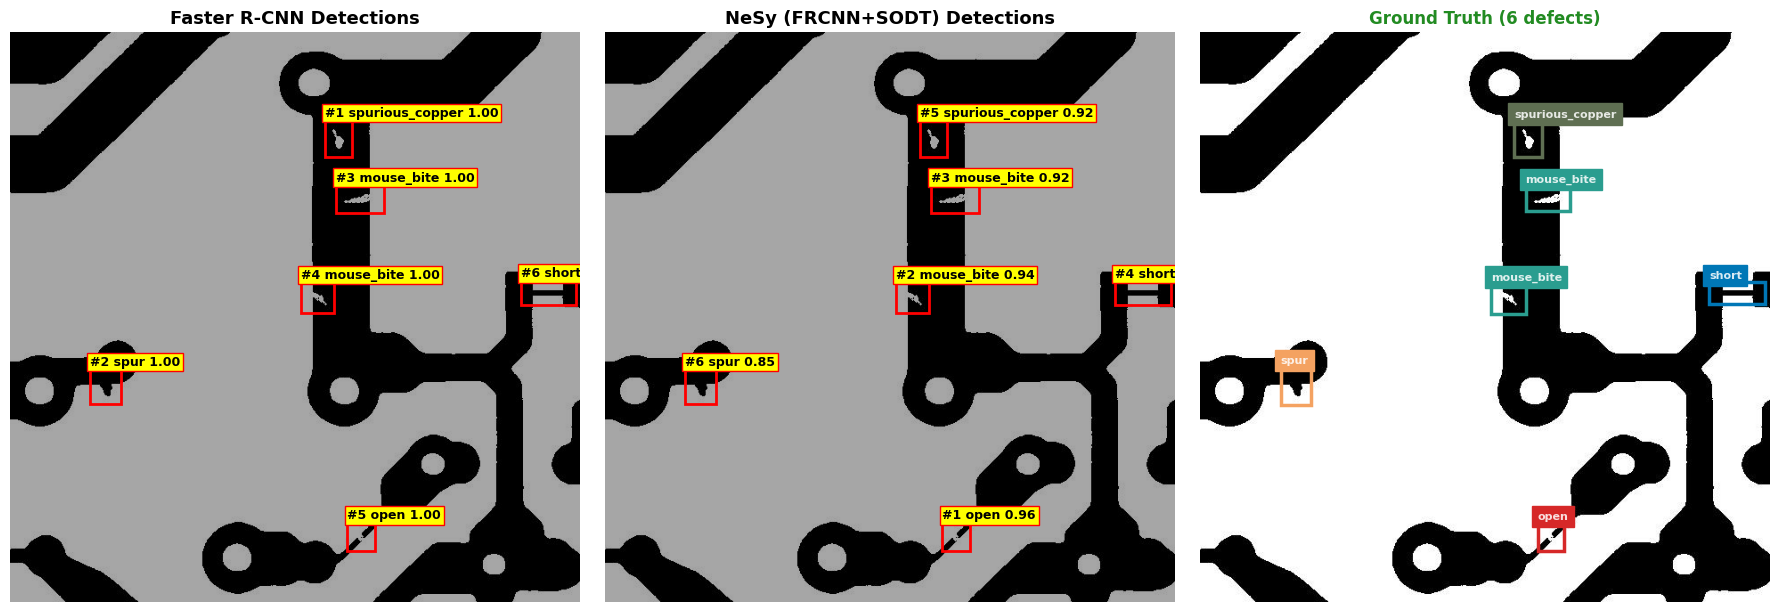

── Explanation ──


Output()


Test Image #57  (FRCNN: 41.1 | NeSy: 43.2 | GradCAM: 161.9 | Total: 246.1 ms)

── Detection ──


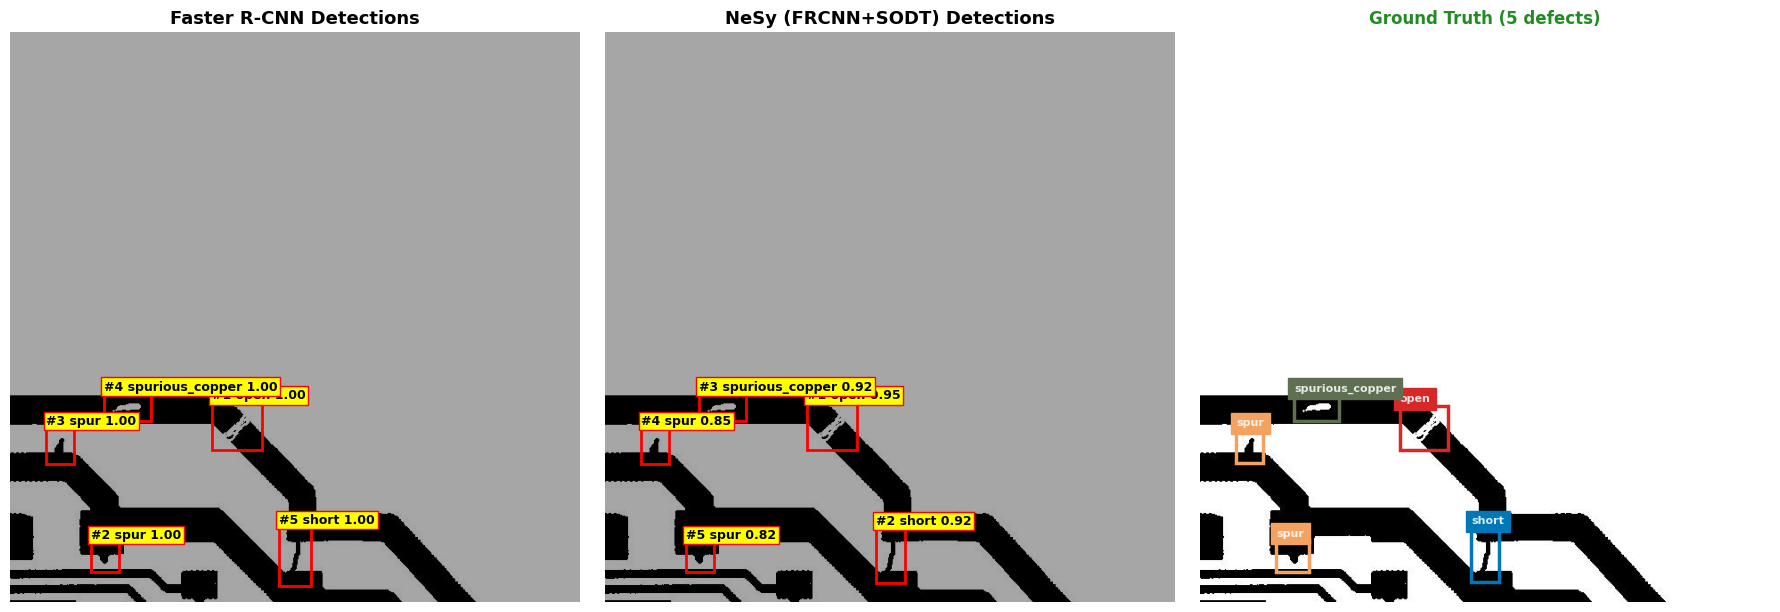

── Explanation ──


Output()


Test Image #12  (FRCNN: 50.7 | NeSy: 46.5 | GradCAM: 190.3 | Total: 287.6 ms)

── Detection ──


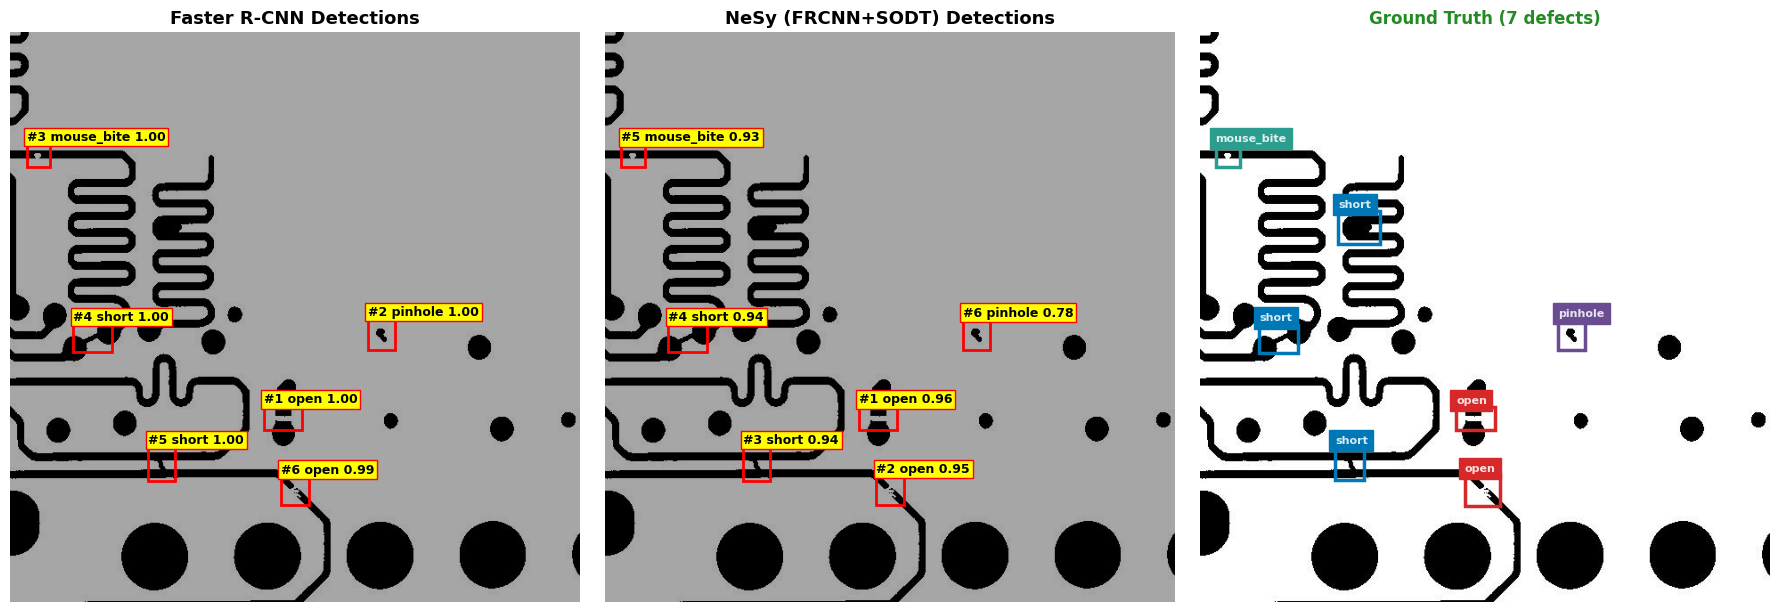

── Explanation ──


Output()


Test Image #379  (FRCNN: 41.3 | NeSy: 47.4 | GradCAM: 190.4 | Total: 279.0 ms)

── Detection ──


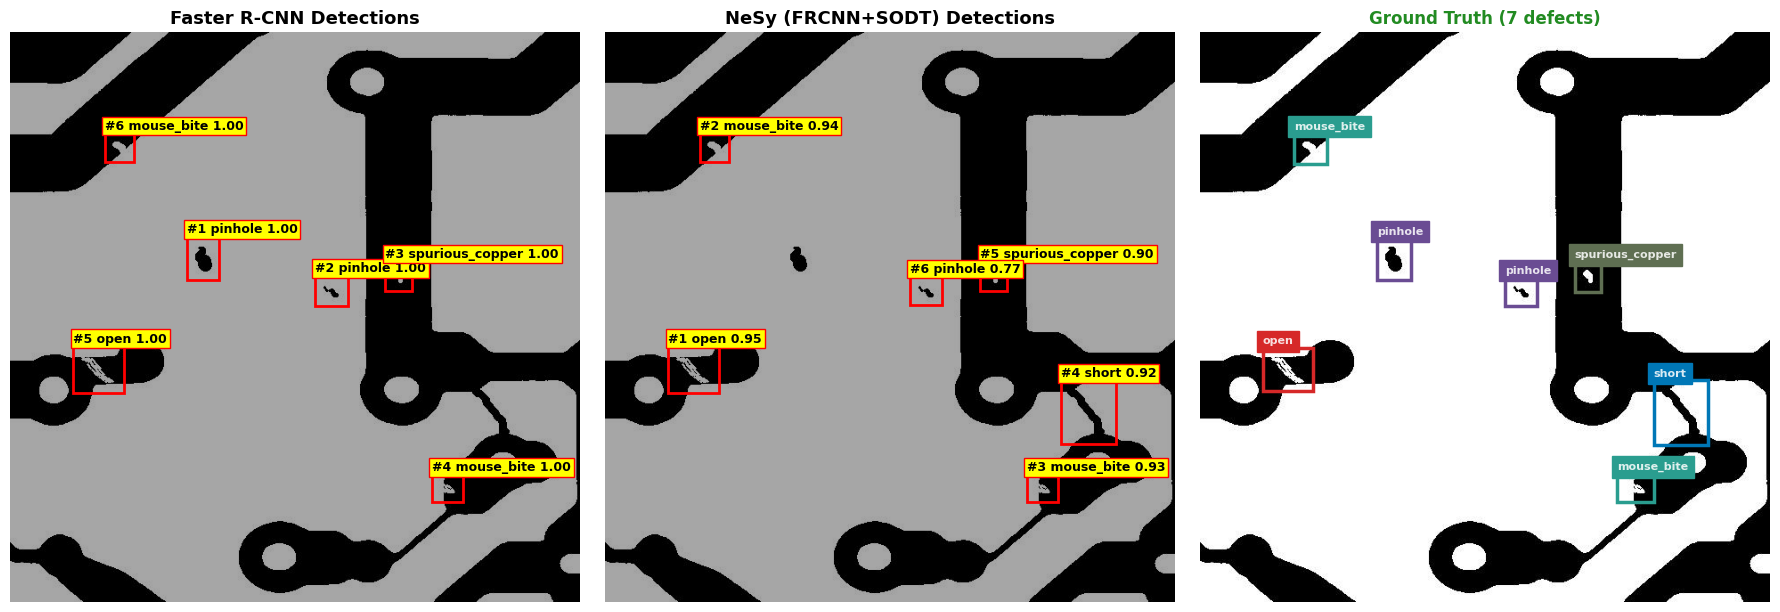

── Explanation ──


Output()


────────────────────────────────────────────────────────────────────────────────
Per-Image Inference Time (ms)
────────────────────────────────────────────────────────────────────────────────
  Faster R-CNN               avg: 42.7 ms  min: 37.8 ms  max: 50.7 ms
  NeSy (FRCNN+SODT)          avg: 44.9 ms  min: 42.6 ms  max: 47.4 ms
  GradCAM (FRCNN+GradCAM)    avg: 183.4 ms  min: 161.9 ms  max: 191.1 ms
  TOTAL                      avg: 271.1 ms  min: 246.1 ms  max: 287.6 ms
────────────────────────────────────────────────────────────────────────────────
Image         FRCNN     NeSy  GradCAM    Total
  #327          37.8     42.6    191.1    271.5
  #57           41.1     43.2    161.9    246.1
  #12           50.7     46.5    190.3    287.6
  #379          41.3     47.4    190.4    279.0


In [8]:
MAX_DETECTIONS = 6

frcnn_times = []
nesy_times = []
gradcam_times = []


def _draw_gradcam_panel_in_axis(ax, image_tensor, gcam_result, class_names):
    from neurosym.heatmap import project_heatmap_to_image

    img = image_to_array(image_tensor)
    ax.imshow(img)

    dimmer = np.zeros((img.shape[0], img.shape[1], 4), dtype=np.float32)
    dimmer[..., 3] = 0.4
    ax.imshow(dimmer)

    heatmap_tensor = gcam_result["heatmap"]
    box = gcam_result["box"]
    image_shape = tuple(image_tensor.shape[-2:])

    projected = project_heatmap_to_image(heatmap_tensor, box, image_shape)

    rgba = heatmap_to_array(projected)
    ax.imshow(rgba)

    x1, y1, x2, y2 = box.tolist()
    ax.add_patch(
        patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="cyan",
            facecolor="none",
        )
    )

    zoom_axis_to_box(ax, box, image_shape)
    label = gcam_result["label"]
    score = gcam_result["score"]
    name = class_names[label - 1] if 0 < label <= len(class_names) else f"cls{label}"
    ax.set_title(
        f"Grad-CAM Focus\n{name} {score:.2f}",
        fontsize=10,
        fontweight="bold",
        color="#c62828",
    )
    ax.axis("off")


def _draw_gt_panel(ax, image_tensor, target, class_names):
    """Draw ground-truth annotations on the image."""
    img = image_to_array(image_tensor)
    ax.imshow(img)
    gt_boxes = target["boxes"]
    gt_labels = target["labels"]
    palette = ["#d62828", "#0077b6", "#2a9d8f", "#f4a261", "#6a4c93", "#5f6f52"]
    for i in range(gt_boxes.shape[0]):
        x1, y1, x2, y2 = gt_boxes[i].tolist()
        lbl = int(gt_labels[i])
        name = class_names[lbl - 1] if 0 < lbl <= len(class_names) else f"cls{lbl}"
        color = palette[(lbl - 1) % len(palette)]
        ax.add_patch(
            patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2.5,
                edgecolor=color,
                facecolor="none",
            )
        )
        ax.text(
            x1,
            max(y1 - 4, 10),
            name,
            fontsize=8,
            fontweight="bold",
            color="white",
            backgroundcolor=color,
            alpha=0.85,
        )
    ax.set_title(
        f"Ground Truth ({gt_boxes.shape[0]} defects)",
        fontsize=12,
        fontweight="bold",
        color="#228B22",
    )
    ax.axis("off")


for sample_idx in sample_indices:
    image_tensor, target = test_dataset[sample_idx]
    image_shape = tuple(image_tensor.shape[-2:])

    # ---------- (A) Pure Faster R-CNN inference ----------
    t0 = _time.perf_counter()
    with torch.inference_mode():
        frcnn_preds = frcnn_model([image_tensor.to(device)])
        frcnn_det = {k: v.detach().cpu() for k, v in frcnn_preds[0].items()}
    _sync()
    t_frcnn = (_time.perf_counter() - t0) * 1000
    frcnn_times.append(t_frcnn)

    # ---------- (B) NeSy: detection + explanation (timed); display maps (untimed) ----------
    t0 = _time.perf_counter()
    hybrid_model.keep_fpn_on_device = True  # FPN maps on the model's device, not copied to CPU
    try:
        with torch.inference_mode():
            hybrid_preds = run_neurosymbolic_inference(
                hybrid_model, [image_tensor.to(device)]
            )
            hybrid_det = hybrid_preds[0]
    finally:
        hybrid_model.keep_fpn_on_device = False
    sodt_indices = select_detection_indices(
        hybrid_det,
        score_threshold=SCORE_THRESHOLD,
        max_detections=MAX_DETECTIONS,
    )
    compute_node_fpn_maps(hybrid_model, hybrid_det, sodt_indices)
    _sync()
    t_nesy = (_time.perf_counter() - t0) * 1000
    nesy_times.append(t_nesy)

    # Per-node panels, grid maps and projections for the figures below — not timed.
    sodt_explanations = explain_hybrid_detections(
        hybrid_model,
        hybrid_det,
        image_shape=image_shape,
        detection_indices=sodt_indices,
        mode="local_instance_evidence_map",
        use_fpn_heatmap=USE_FPN_HEATMAP,
    )

    # Each model's own detections — indices never carry across models.
    frcnn_indices = select_detection_indices(
        frcnn_det,
        score_threshold=SCORE_THRESHOLD,
        max_detections=MAX_DETECTIONS,
    )

    # Grad-CAM pipeline time = FRCNN detection (t_frcnn) + one map per FRCNN detection.
    t0 = _time.perf_counter()
    gradcam.generate(
        image_tensor,
        frcnn_det["proposal_boxes_processed"][frcnn_indices],
        frcnn_det["labels"][frcnn_indices],
    )
    _sync()
    t_gradcam = t_frcnn + (_time.perf_counter() - t0) * 1000
    gradcam_times.append(t_gradcam)

    # ---------- (C) Grad-CAM display (on NeSy's detections, untimed) ----------
    # Same detection, explained at its proposal (where the class call was made).
    boxes_selected = hybrid_det["proposal_boxes"][sodt_indices]
    proposals_selected = hybrid_det["proposal_boxes_processed"][sodt_indices]
    labels_selected = hybrid_det["labels"][sodt_indices]
    scores_selected = hybrid_det["scores"][sodt_indices]

    if len(sodt_indices) > 0:
        gcam_heatmaps = gradcam.generate(
            image_tensor,
            proposals_selected,
            labels_selected,
        )
        gcam_results = [
            {
                "box": boxes_selected[i].detach().cpu(),
                "label": int(labels_selected[i]),
                "score": float(scores_selected[i]),
                "heatmap": gcam_heatmaps[i],
            }
            for i in range(len(sodt_indices))
        ]
    else:
        gcam_results = []

    print(f"\n{'=' * 100}")
    print(
        f"Test Image #{sample_idx}  (FRCNN det: {t_frcnn:.1f} | NeSy det+expl: {t_nesy:.1f} | Grad-CAM det+expl: {t_gradcam:.1f} ms)"
    )
    print(f"{'=' * 100}\n")

    # ═══════════════════════════════════════════════════════════
    # DETECTION SECTION: FRCNN | NeSy | Ground Truth
    # ═══════════════════════════════════════════════════════════
    print("── Detection ──")
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    draw_numbered_detections(
        axes[0], image_tensor, frcnn_det, frcnn_indices, class_names
    )
    axes[0].set_title("Faster R-CNN Detections", fontsize=13, fontweight="bold")

    draw_numbered_detections(
        axes[1], image_tensor, hybrid_det, sodt_indices, class_names
    )
    axes[1].set_title("NeSy (FRCNN+SODT) Detections", fontsize=13, fontweight="bold")

    _draw_gt_panel(axes[2], image_tensor, target, class_names)

    plt.tight_layout()
    plt.show()

    # ═══════════════════════════════════════════════════════════
    # EXPLANATION SECTION: SODT Tree+Heatmap | GradCAM Heatmap
    # ═══════════════════════════════════════════════════════════
    print("── Explanation ──")
    if len(sodt_indices) == 0:
        print("No detections above threshold.")
        continue

    out = widgets.Output()

    def make_btn(
        btn_num,
        det_idx,
        expl,
        gcam_res,
        tnsr=image_tensor,
        hyb=hybrid_det,
        out_w=out,
    ):
        label_name = class_names[expl["label"] - 1]
        score = expl["score"]
        btn = widgets.Button(
            description=f"#{btn_num} {label_name} {score:.2f}",
            layout=widgets.Layout(width="180px"),
        )

        def on_click(_):
            with out_w:
                clear_output(wait=True)

                def gcam_panel(ax):
                    _draw_gradcam_panel_in_axis(ax, tnsr, gcam_res, class_names)

                draw_neurosymbolic_explanation(
                    tnsr,
                    hyb,
                    det_idx,
                    expl,
                    class_names,
                    hybrid_model.symbolic_tree,
                    selected_number=btn_num,
                    extra_panel_func=gcam_panel,
                )

        btn.on_click(on_click)
        return btn

    buttons = []
    for btn_num, (det_idx, expl, gcam_res) in enumerate(
        zip(sodt_indices, sodt_explanations, gcam_results), 1
    ):
        buttons.append(make_btn(btn_num, det_idx, expl, gcam_res))

    display(widgets.HBox(buttons))
    display(out)

# ── Inference Time Summary ──
if frcnn_times:

    def _print_stats(name, times):
        arr = np.array(times)
        print(
            f"  {name:<25s}  avg: {arr.mean():.1f} ms  min: {arr.min():.1f} ms  max: {arr.max():.1f} ms"
        )

    print(f"\n{'─' * 80}")
    print("Per-Image Inference Time (ms)")
    print(f"{'─' * 80}")
    _print_stats("Faster R-CNN (det)", frcnn_times)
    _print_stats("NeSy (det + expl)", nesy_times)
    _print_stats("Grad-CAM (det + expl)", gradcam_times)
    print(f"{'─' * 80}")
    print(f"{'Image':<10s} {'FRCNN':>8s} {'NeSy':>8s} {'GradCAM':>8s}")
    for idx, tf, tn, tg in zip(sample_indices, frcnn_times, nesy_times, gradcam_times):
        print(f"  #{idx:<8d} {tf:>8.1f} {tn:>8.1f} {tg:>8.1f}")
else:
    print("No images processed.")

## 6. Interactive Comparison (Upload Image)
Upload runs all three pipes (FRCNN · NeSy · GradCAM): detection (FRCNN | NeSy),
explanation per detection (tree + heatmap | GradCAM).

In [9]:
# ── Interactive Three-Way Comparison on Uploaded Image ──
# Upload a PCB image → automatically runs Pure FRCNN · NeSy (FRCNN+SODT) · GradCAM.
# Shows detection comparison and per-detection explanations.
# Cleanup: close all prior figures and clear outputs on every cell re-run.

import io
from PIL import Image
from neuro.inference import run_inference
from neurosym.heatmap import project_heatmap_to_image

plt.close("all")
clear_output(wait=True)

INT_SCORE_THRESHOLD = 0.3
INT_MAX_DETECTIONS = 15

int_upload = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload PCB Image",
)
int_output = widgets.Output()
expl_output = widgets.Output()
_processing_upload = False


def _int_file_record():
    value = int_upload.value
    if isinstance(value, tuple):
        return value[0] if value else None
    if isinstance(value, dict):
        if "content" in value:
            return value
        return next(iter(value.values())) if value else None
    return None


def _int_content_bytes(file_record) -> bytes:
    content = file_record["content"]
    return content.tobytes() if isinstance(content, memoryview) else bytes(content)


def _int_draw_gradcam_panel(ax, image_tensor, gcam_result, class_names):
    """Draw a single GradCAM heatmap overlay, zoomed to the detection box."""
    img = image_to_array(image_tensor)
    ax.imshow(img)
    dimmer = np.zeros((img.shape[0], img.shape[1], 4), dtype=np.float32)
    dimmer[..., 3] = 0.4
    ax.imshow(dimmer)
    heatmap_tensor = gcam_result["heatmap"]
    box = gcam_result["box"]
    image_shape = tuple(image_tensor.shape[-2:])
    projected = project_heatmap_to_image(heatmap_tensor, box, image_shape)
    rgba = heatmap_to_array(projected)
    ax.imshow(rgba)
    x1, y1, x2, y2 = box.tolist()
    ax.add_patch(
        patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="cyan",
            facecolor="none",
        )
    )
    zoom_axis_to_box(ax, box, image_shape)
    label = gcam_result["label"]
    score = gcam_result["score"]
    name = class_names[label - 1] if 0 < label <= len(class_names) else f"cls{label}"
    ax.set_title(
        f"GradCAM: {name} {score:.2f}",
        fontsize=11,
        fontweight="bold",
        color="cyan",
    )
    ax.axis("off")


def _on_upload_change(change):
    global _processing_upload
    if _processing_upload:
        return
    if not change.get("new"):
        return
    _processing_upload = True
    try:
        with int_output:
            from IPython.display import clear_output

            clear_output(wait=True)
            expl_output.clear_output(wait=True)
            plt.close("all")

            file_record = _int_file_record()
            if file_record is None:
                print("Upload a PCB image first.")
                return

            image_name = file_record.get("name", "uploaded_image")
            pil_image = Image.open(io.BytesIO(_int_content_bytes(file_record))).convert(
                "RGB"
            )
            image_tensor = preprocess(pil_image)
            image_shape = tuple(image_tensor.shape[-2:])
            print(f"Image: {image_name}")

            # ═══════════════════════════════════════════
            # (A) Pure Faster R-CNN
            # ═══════════════════════════════════════════
            t0 = _time.perf_counter()
            frcnn_det = run_inference(frcnn_model, [image_tensor], device)[0]
            _sync()
            t_frcnn = (_time.perf_counter() - t0) * 1000

            # ═══════════════════════════════════════════
            # (B) NeSy (FRCNN + SODT): detection + explanation (timed); display maps (untimed)
            # ═══════════════════════════════════════════
            t0 = _time.perf_counter()
            hybrid_model.keep_fpn_on_device = True  # FPN maps on the model's device, not copied to CPU
            try:
                hybrid_det = run_neurosymbolic_inference(hybrid_model, [image_tensor])[0]
            finally:
                hybrid_model.keep_fpn_on_device = False
            sel_indices = select_detection_indices(
                hybrid_det,
                score_threshold=INT_SCORE_THRESHOLD,
                max_detections=INT_MAX_DETECTIONS,
            )
            compute_node_fpn_maps(hybrid_model, hybrid_det, sel_indices)
            _sync()
            t_nesy = (_time.perf_counter() - t0) * 1000

            # Per-node panels, grid maps and projections for the figures below — not timed.
            sel_explanations = explain_hybrid_detections(
                hybrid_model,
                hybrid_det,
                image_shape=image_shape,
                detection_indices=sel_indices,
                mode="local_instance_evidence_map",
                use_fpn_heatmap=USE_FPN_HEATMAP,
            )

            # Each model's own detections — indices never carry across models.
            frcnn_sel_indices = select_detection_indices(
                frcnn_det,
                score_threshold=INT_SCORE_THRESHOLD,
                max_detections=INT_MAX_DETECTIONS,
            )

            # Grad-CAM pipeline time = FRCNN detection (t_frcnn) + one map per FRCNN detection.
            t0 = _time.perf_counter()
            gradcam.generate(
                image_tensor,
                frcnn_det["proposal_boxes_processed"][frcnn_sel_indices],
                frcnn_det["labels"][frcnn_sel_indices],
            )
            _sync()
            t_gradcam = t_frcnn + (_time.perf_counter() - t0) * 1000

            # ═══════════════════════════════════════════
            # (C) Grad-CAM display (on NeSy's detections, untimed)
            # ═══════════════════════════════════════════
            boxes_sel = hybrid_det["proposal_boxes"][sel_indices]
            proposals_sel = hybrid_det["proposal_boxes_processed"][sel_indices]
            labels_sel = hybrid_det["labels"][sel_indices]
            if len(sel_indices) > 0:
                gcam_heatmaps = gradcam.generate(image_tensor, proposals_sel, labels_sel)
                gcam_results = [
                    {
                        "box": boxes_sel[j].detach().cpu(),
                        "label": int(labels_sel[j]),
                        "score": float(hybrid_det["scores"][sel_indices[j]]),
                        "heatmap": gcam_heatmaps[j],
                    }
                    for j in range(len(sel_indices))
                ]
            else:
                gcam_results = []

            print(
                f"FRCNN det: {t_frcnn:.1f} ms | NeSy det+expl: {t_nesy:.1f} ms "
                f"| Grad-CAM det+expl: {t_gradcam:.1f} ms"
            )
            print(f"Detections above threshold: {len(sel_indices)}\n")

            # ═══════════════════════════════════════════
            # (GT) Ground Truth Lookup
            # ═══════════════════════════════════════════
            gt_info = lookup_ground_truth(test_dataset, image_name)

            # ═══════════════════════════════════════════
            # DETECTION SECTION: FRCNN | NeSy | Ground Truth
            # ═══════════════════════════════════════════
            print("── Detection ──")
            if gt_info is not None:
                gt_boxes, gt_labels = gt_info
                fig, axes = plt.subplots(1, 3, figsize=(20, 6))

                draw_numbered_detections(
                    axes[0], image_tensor, frcnn_det, frcnn_sel_indices, class_names
                )
                axes[0].set_title(
                    "Faster R-CNN Detections", fontsize=13, fontweight="bold"
                )

                draw_numbered_detections(
                    axes[1], image_tensor, hybrid_det, sel_indices, class_names
                )
                axes[1].set_title(
                    "NeSy (FRCNN+SODT) Detections", fontsize=13, fontweight="bold"
                )

                draw_ground_truth_boxes(
                    axes[2], image_tensor, gt_boxes, gt_labels, class_names
                )
                axes[2].set_title("Ground Truth", fontsize=13, fontweight="bold")
            else:
                fig, axes = plt.subplots(1, 2, figsize=(14, 6))

                draw_numbered_detections(
                    axes[0], image_tensor, frcnn_det, frcnn_sel_indices, class_names
                )
                axes[0].set_title(
                    "Faster R-CNN Detections", fontsize=13, fontweight="bold"
                )

                draw_numbered_detections(
                    axes[1], image_tensor, hybrid_det, sel_indices, class_names
                )
                axes[1].set_title(
                    "NeSy (FRCNN+SODT) Detections", fontsize=13, fontweight="bold"
                )

            plt.tight_layout()
            plt.show()

            # ═══════════════════════════════════════════
            # EXPLANATION SECTION: per-detection buttons
            # ═══════════════════════════════════════════
            if not sel_indices:
                print("No detections above threshold — skipping explanations.")
                return

            print("── Explanation ──")

            def make_int_btn(btn_num, det_idx, expl, gcam_res, tnsr, hyb):
                label_name = class_names[expl["label"] - 1]
                score = expl["score"]
                btn = widgets.Button(
                    description=f"#{btn_num} {label_name} {score:.2f}",
                    layout=widgets.Layout(width="180px"),
                )

                def on_click(
                    _,
                    _tnsr=tnsr,
                    _hyb=hyb,
                    _det_idx=det_idx,
                    _expl=expl,
                    _gcam_res=gcam_res,
                    _btn_num=btn_num,
                ):
                    with expl_output:
                        clear_output(wait=True)

                        def gcam_panel(ax):
                            _int_draw_gradcam_panel(ax, _tnsr, _gcam_res, class_names)

                        draw_neurosymbolic_explanation(
                            _tnsr,
                            _hyb,
                            _det_idx,
                            _expl,
                            class_names,
                            hybrid_model.symbolic_tree,
                            selected_number=_btn_num,
                            extra_panel_func=gcam_panel,
                        )

                btn.on_click(on_click)
                return btn

            buttons = []
            for btn_num, (det_idx, expl, gcam_res) in enumerate(
                zip(sel_indices, sel_explanations, gcam_results), 1
            ):
                buttons.append(
                    make_int_btn(
                        btn_num, det_idx, expl, gcam_res, image_tensor, hybrid_det
                    )
                )

            display(widgets.HBox(buttons))
            display(expl_output)
    finally:
        _processing_upload = False


int_upload.observe(_on_upload_change, names="value")

display(
    widgets.VBox(
        [
            widgets.HTML("<b>Upload a PCB image — inference runs automatically</b>"),
            int_upload,
            int_output,
        ]
    )
)

## 7. Cleanup